# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [4]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [6]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2893s 17us/step
X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [7]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:**

La imagen en escala de grises tiene un tamaño de 32 × 32 píxeles, cuando nosotros aplicamos Flatten, se convierte en un vector 32 X 32 = 1024 valores.


## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [8]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


In [9]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


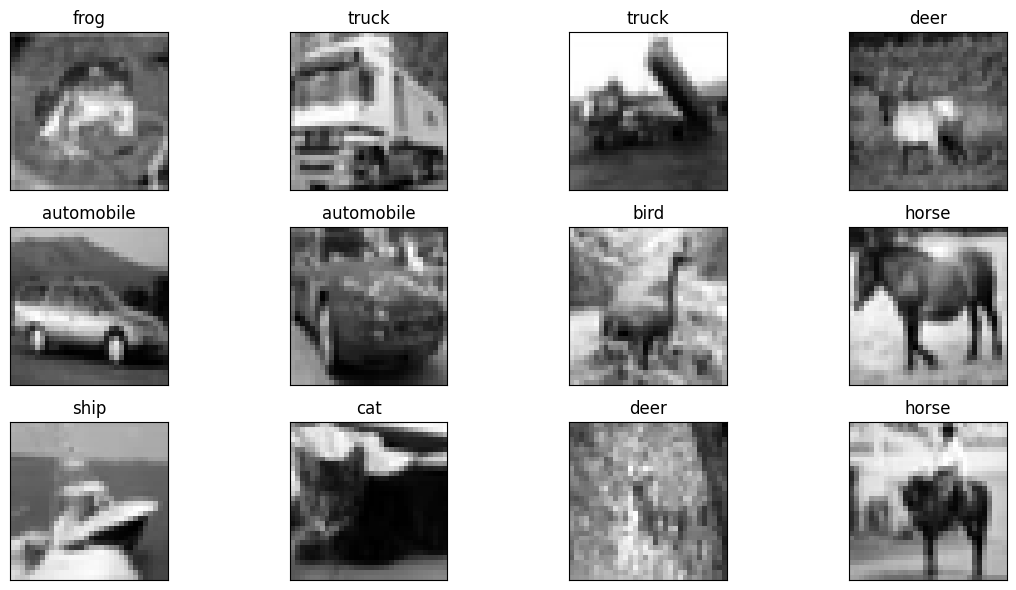

In [10]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [11]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**

La capa Flatten convierte la imagen de 32 × 32 en un vector de 1024 valores y es necesaria porque las capas Dense reciben los datos como un vector de entrada y no como una matriz de píxeles.


**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:**

La última capa tiene 10 neuronas porque CIFAR-10 tiene 10 clases diferentes y Cada neurona representa una clase y su salida es un logit que indica qué tan relacionada está la imagen con esa clase.


**4.** ¿Qué función cumple `ReLU`?

**Respuesta:**

Hace que los valores negativos se convierten en 0, mientras que los valores positivos se mantienen.



---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [13]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:**

Porque la última capa del modelo no utiliza Softmax sino que entrega directamente los logits. por eso Al usar from_logits=True, la función SparseCategoricalCrossentropy sabe que debe trabajar directamente con esos valores.



---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [22]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4099 - loss: 1.6655 - val_accuracy: 0.3783 - val_loss: 1.7500
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4103 - loss: 1.6635 - val_accuracy: 0.3773 - val_loss: 1.7485
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4109 - loss: 1.6616 - val_accuracy: 0.3783 - val_loss: 1.7496
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4126 - loss: 1.6580 - val_accuracy: 0.3755 - val_loss: 1.7532
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4139 - loss: 1.6552 - val_accuracy: 0.3756 - val_loss: 1.7545
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4166 - loss: 1.6514 - val_accuracy: 0.3762 - val_loss: 1.7527
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4169 - loss: 1.6479 - val_accuracy: 0.3767 - val_loss: 1.7529
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4187 - loss: 1.6447 - val_accuracy: 0.

### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:**

Representa una época y esta es una pasada completa por todo el conjunto de datos de entrenamiento.


**7.** ¿Qué representa `batch_size=64`?

**Respuesta:**
Significa que el modelo procesa 64 imágenes a la vez antes de realizar una actualización de los pesos de la red.



## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


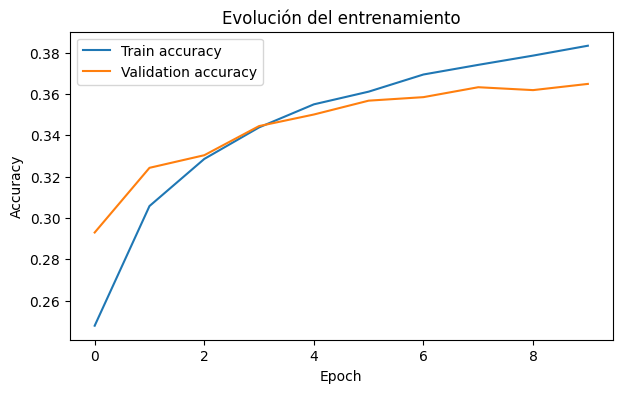

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:**

Sí, puede observarse cierto overfitting si la precisión de entrenamiento continúa aumentando mientras la precisión de validación se estanca o mejora mucho menos. Esto significa que el modelo está aprendiendo muy bien los datos de entrenamiento, pero no mejora en la misma proporción con datos que no utilizó directamente para ajustar sus pesos.



---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [16]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 1.7809
Test accuracy : 0.3649
Accuracy (%)  : 36.49%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:**
CIFAR-10 en escala de grises parece ser más difícil para esta red que Fashion-MNIST ya que el accuracy obtenido en CIFAR-10 es menor. Esto se debe a que las imágenes de CIFAR-10 contienen objetos más variados y complejos y al convertirlas a escala de grises se pierde información del color que podría ayudar a clasificarlos.


---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


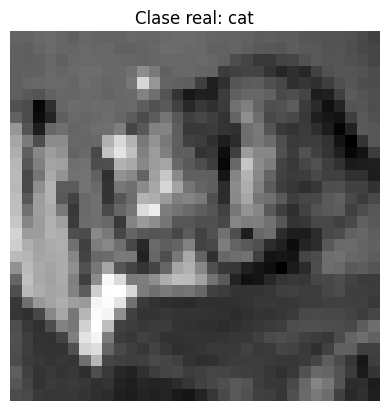

Logits:
[[ 0.9981753  -1.5947696   1.5758052   0.24392425  1.1962814   0.2162365
   0.43944997  0.40920818 -0.13240755 -1.952623  ]]


In [17]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [18]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])

Clase real     : cat
Clase predicha : bird


In [19]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.1537
automobile  : 0.0115
bird        : 0.2739 ← predicción
cat         : 0.0723
deer        : 0.1874
dog         : 0.0703
frog        : 0.0879
horse       : 0.0853
ship        : 0.0496
truck       : 0.0080

Suma: 0.9999999


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:**

Porque Softmax normaliza los logits y los convierte en probabilidades. Por eso las probabilidades de las 10 clases suman aproximadamente 1.

---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


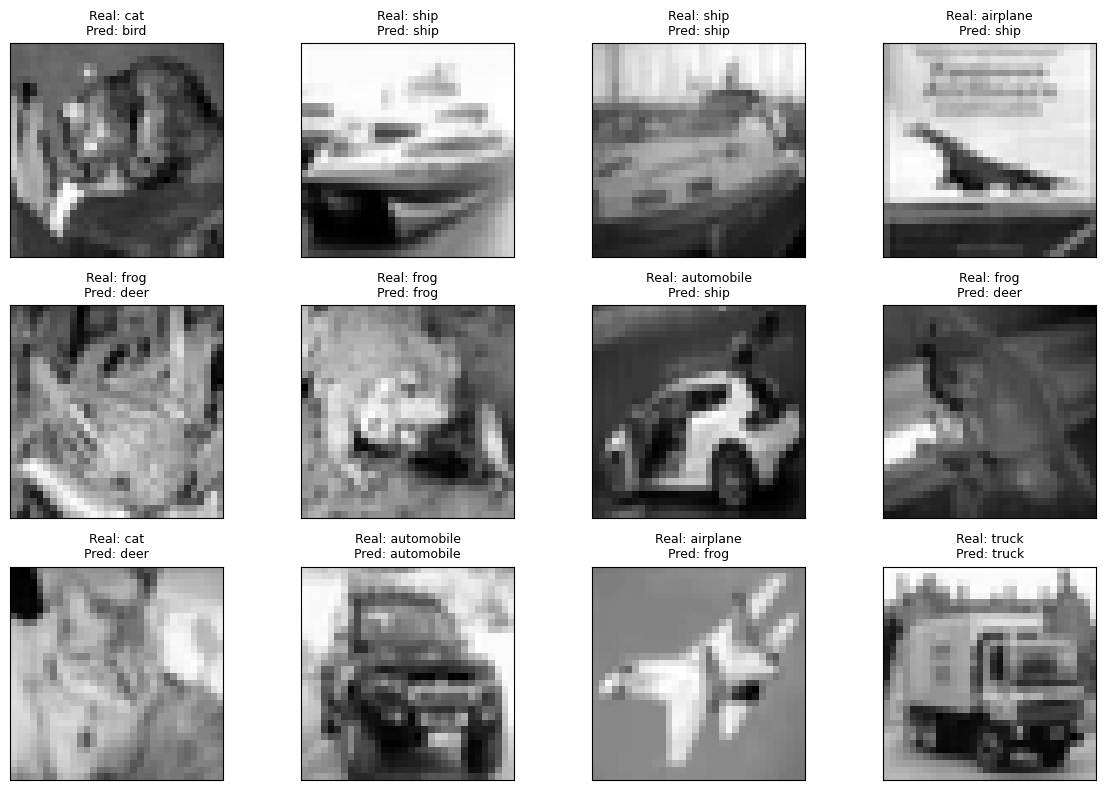

In [20]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:**

Test accuracy : 0.3649
Accuracy (%)  : 36.49%


### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:**

Las clases como cat, dog, deer y horse, pueden ser difíciles de distinguir porque sus características visuales pueden ser similares. Además al trabajar en escala de grises se pierde información del color.


### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:**

Al aplicar Flatten se pierde la estructura espacial explícita de la imagen. El modelo recibe los píxeles como un vector y ya no tiene directamente la información de cuáles píxeles están cerca de otros en la imagen.


### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:**

Una CNN puede aprovechar la estructura espacial de las imágenes mediante filtros y convoluciones. Esto le permite detectar patrones locales como bordes, formas y texturas que es algo que una red que primero aplica Flatten no aprovecha de la misma manera.

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.
